In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load data from GitHub 
data = pd.read_csv("https://raw.githubusercontent.com/HamzaSa1t/Income-classification---Logistic-Regression/main/adult_data.csv")
display(data.head())

,Unnamed: 0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [74]:
data = data.drop('fnlwgt', axis=1)

data.replace('?', np.nan, inplace=True)
data['native-country'].replace('?', np.nan, inplace=True)


# remove rows without: workclass / occupation
data.dropna(subset=['workclass', 'occupation'], inplace=True)

# Fill missing values based on Mode for each Race group
data['native-country'] = data['native-country'].fillna( 
    data.groupby('race')['native-country'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# if any missing values remain fill with the overall mode of the column
data['native-country'].fillna(data['native-country'].mode()[0], inplace=True)


print("columns with missing values number:")
print(data.isnull().sum())

columns with missing values number:
Unnamed: 0        0
age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_16188\1153051697.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['native-country'].replace('?', np.nan, inplace=True)
C:\Users\Hamza\AppData\Local\Temp\ipykernel_16188\1153051697.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained 

In [75]:
data = data.drop('marital-status', axis=1)

# Perform one-hot encoding
columns_to_encode = ['workclass', 'sex', 'race', 'occupation']
data = pd.get_dummies(data, columns=columns_to_encode, drop_first=True)

developed_countries = ['Holand-Netherlands','Poland', 'Yugoslavia', 'Canada', 'England', 'Germany', 'South-Korea', 'Italy', 'Japan', 'France', 'Ireland', 'Hungary', 'Greece', 'Portugal', 'Scotland', 'Taiwan', 'Hong']
developing_countries = ['India','Trinadad&Tobago','Outlying-US', 'South', 'China', 'Philippines', 'Vietnam', 'El-Salvador', 'Puerto-Rico', 'Columbia', 'Guatemala', 'Cuba', 'Jamaica', 'Dominican-Republic', 'Honduras', 'Ecuador', 'Peru', 'Nicaragua', 'Laos', 'Thailand', 'Iran', 'Haiti', 'Cambodia', 'Outlying-US(Guam-USVI-etc)']

def group_country(country):
    if country == 'United-States':
        return 'United-States'
    elif country == 'Mexico':
        return 'Mexico'
    elif country in developed_countries:
        return 'Developed Countries'
    elif country in developing_countries:
        return 'Developing Countries'
    else:
        return 'Other'

data['native_country_grouped'] = data['native-country'].apply(group_country)
data = pd.get_dummies(data, columns=['native_country_grouped'], drop_first=True)

data = pd.get_dummies(data, columns=['relationship'], drop_first=True)


display(data.head())
print(data.shape)

,Unnamed: 0,age,education,education-num,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,native_country_grouped_Developing Countries,native_country_grouped_Mexico,native_country_grouped_United-States,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,0,39,Bachelors,13,2174,0,40,United-States,<=50K,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False
1,1,50,Bachelors,13,0,0,13,United-States,<=50K,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,2,38,HS-grad,9,0,0,40,United-States,<=50K,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False
3,3,53,11th,7,0,0,40,United-States,<=50K,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,4,28,Bachelors,13,0,0,40,Cuba,<=50K,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True


(46033, 41)


In [76]:
# Encode 'income' as a binary target
data["income"] = data["income"].str.replace(".", "", regex=False)
data['income'] = data['income'].map({'<=50K': 0, '>50K': 1})

# Drop unnecessary columns
data = data.drop('native-country', axis=1)
data = data.drop('education', axis=1)
data = data.drop('Unnamed: 0', axis=1)

# split data:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)
y_train = X_train['income']
X_train = X_train.drop('income', axis=1)
y_test = X_test['income']
X_test = X_test.drop('income', axis=1)

In [77]:
# Apply scaling to the numrical features in X:
features_to_scale = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

display(X_train.head())

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,native_country_grouped_Developing Countries,native_country_grouped_Mexico,native_country_grouped_United-States,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
26660,-1.104687,0.340655,-0.147257,-0.219090,-0.244052,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
32838,-1.558266,-1.217920,-0.147257,-0.219090,-1.410673,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
11091,0.785223,-0.048989,-0.147257,4.347888,0.255928,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False
34491,1.087608,-0.438632,-0.147257,-0.219090,-0.077392,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
23197,-0.651109,-0.438632,-0.147257,-0.219090,1.172558,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False


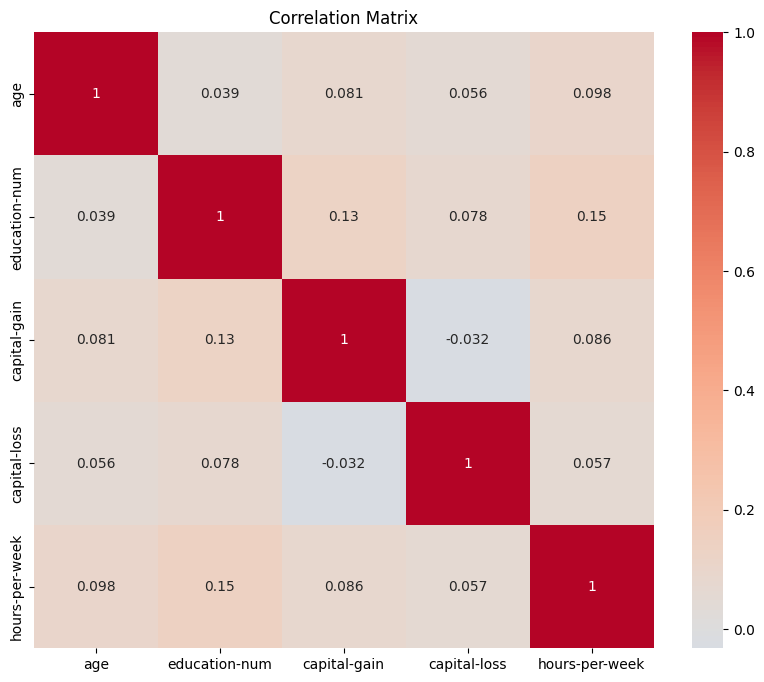

                     age  education-num  capital-gain  capital-loss  hours-per-week
age             1.000000       0.038787      0.081263      0.056194        0.097815
education-num   0.038787       1.000000      0.127768      0.078193        0.146608
capital-gain    0.081263       0.127768      1.000000     -0.032263        0.085659
capital-loss    0.056194       0.078193     -0.032263      1.000000        0.056753
hours-per-week  0.097815       0.146608      0.085659      0.056753        1.000000


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix (numerical columns)
numerical_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
correlation_matrix = X_train[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
print(correlation_matrix)

In [79]:
# Calculate correlation with target
features_to_check = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

correlations = X_test[features_to_check].corrwith(y_test)
correlations = correlations.sort_values(ascending=False)

print(correlations)

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

# Calculate permutation importance
result = permutation_importance(clf, X_test, y_test, random_state=42)

# Display results
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance_df)

education-num     0.326426
age               0.234166
capital-gain      0.217336
hours-per-week    0.215055
capital-loss      0.163230
dtype: float64
                                        feature    importance
1                                 education-num  3.301836e-02
32                   relationship_Not-in-family  3.277941e-02
2                                  capital-gain  3.056370e-02
34                       relationship_Own-child  1.566200e-02
35                       relationship_Unmarried  1.020962e-02
8                    workclass_Self-emp-not-inc  6.451613e-03
3                                  capital-loss  5.495818e-03
18                   occupation_Exec-managerial  5.365483e-03
11                                     sex_Male  4.192462e-03
36                            relationship_Wife  3.823178e-03
4                                hours-per-week  3.062887e-03
24                    occupation_Prof-specialty  2.867384e-03
0                                           

In [80]:
# Sigmoid function
def sigmoid(x):
    y = 1 / (1 + np.exp(-x))

    return y

In [81]:
# compute_cost
import numpy as np
def compute_cost(X, y, w, b, *argv):
    m, n = X.shape

    fx = np.dot(X, w) + b
    fx2 = sigmoid(fx)
    fx2 = np.clip(fx2, 1e-15, 1 - 1e-15)  # prevent log(0)

    total_cost = 0
    for x in range(len(fx2)):
        loss = (-y[x] * np.log(fx2[x]) - (1 - y[x]) * np.log(1 - fx2[x]))
        total_cost += loss

    total_cost = total_cost / m
    return total_cost

In [82]:
# gradient decent
import math

def gradient_descent(X, y, w, b, alpha, num_iters, sigmoid):
   m, n = X.shape
   J_history = []
   w_history = []

   for i in range(num_iters):
        fx = np.dot(X, w) + b
        fx2 = sigmoid(fx)
         
        dj_db = (fx2 - y).mean()
        dj_dw = np.dot(X.T, (fx2 - y)) / m

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            cost = compute_cost(X, y, w, b)
            J_history.append(cost)

        if i % math.ceil(num_iters / 10) == 0 or i == (num_iters - 1):
            w_history.append(w.copy())
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

   return w, b

In [83]:
# regularized cost function
def compute_cost_reg(X, y, w, b, lambda_):
    m, n = X.shape

    fx = np.dot(X, w) + b
    fx2 = sigmoid(fx)
    fx2 = np.clip(fx2, 1e-15, 1 - 1e-15)  # prevent log(0)

    total_cost = 0
    for i in range(m):
        loss = -y[i] * np.log(fx2[i]) - (1 - y[i]) * np.log(1 - fx2[i])
        total_cost += loss
    total_cost = total_cost / m

    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    total_cost = total_cost + reg_cost
    return total_cost


# regularized gradient descent
def gradient_descent_reg(X, y, w, b, alpha, num_iters, lambda_, sigmoid):
    m, n = X.shape
    J_history = []
    w_history = []

    for i in range(num_iters):
        fx = np.dot(X, w) + b
        fx2 = sigmoid(fx)

        dj_db = (fx2 - y).mean()
        dj_dw = np.dot(X.T, (fx2 - y)) / m + (lambda_ / m) * w

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            cost = compute_cost_reg(X, y, w, b, lambda_)
            J_history.append(cost)

        if i % math.ceil(num_iters / 10) == 0 or i == (num_iters - 1):
            w_history.append(w.copy())
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b

# Weighted cost & gradient descent (handles class imbalance)
# w_pos: weight for positive class (>50K), w_neg: for negative

def compute_cost_weighted(X, y, w, b, w_pos, w_neg):
    m, n = X.shape
    fx2 = sigmoid(np.dot(X, w) + b)
    fx2 = np.clip(fx2, 1e-15, 1 - 1e-15)  # prevent log(0)
    weights = np.where(y == 1, w_pos, w_neg)
    losses = -weights * (y * np.log(fx2) + (1 - y) * np.log(1 - fx2))
    return losses.mean()

def gradient_descent_weighted(X, y, w, b, alpha, num_iters, w_pos, w_neg, sigmoid):
    m, n = X.shape
    J_history = []
    weights = np.where(y == 1, w_pos, w_neg)

    for i in range(num_iters):
        fx2 = sigmoid(np.dot(X, w) + b)
        error = fx2 - y

        dj_db = (weights * error).mean()
        dj_dw = np.dot(X.T, weights * error) / m

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            J_history.append(compute_cost_weighted(X, y, w, b, w_pos, w_neg))

        if i % math.ceil(num_iters / 10) == 0 or i == (num_iters - 1):
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b

def gradient_descent_weighted_reg(X, y, w, b, alpha, num_iters, lambda_, w_pos, w_neg, sigmoid):
    m, n = X.shape
    J_history = []
    weights = np.where(y == 1, w_pos, w_neg)

    for i in range(num_iters):
        fx2 = sigmoid(np.dot(X, w) + b)
        error = fx2 - y

        dj_db = (weights * error).mean()
        dj_dw = np.dot(X.T, weights * error) / m + (lambda_ / m) * w

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            J_history.append(compute_cost_weighted(X, y, w, b, w_pos, w_neg))

        if i % math.ceil(num_iters / 10) == 0 or i == (num_iters - 1):
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b

In [84]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, accuracy_score
import numpy as np

def evaluate_model(label, y_test, y_prob):
    """Find best threshold via PR curve and print Acc, F1, Prec, Rec, Thresh, AUC."""
    prec, rec, thresh = precision_recall_curve(y_test, y_prob)
    f1s    = 2 * (prec * rec) / (prec + rec + 1e-15)
    best_i = np.argmax(f1s)
    auc    = roc_auc_score(y_test, y_prob)
    y_pred = (y_prob >= thresh[best_i]).astype(int)
    acc    = accuracy_score(y_test, y_pred)
    print(f"{label:<25} {acc:>6.4f} {f1s[best_i]:>6.4f} {prec[best_i]:>6.4f} {rec[best_i]:>6.4f} {thresh[best_i]:>7.4f} {auc:>6.4f}")
    return acc, f1s[best_i], prec[best_i], rec[best_i], thresh[best_i], auc

In [ ]:
# convert to numpy arrays
X_train_np = X_train.values.astype(float)
y_train_np = y_train.values.astype(float)
X_test_np = X_test.values.astype(float)
y_test_np = y_test.values.astype(float)

# initialize w and b
n = X_train_np.shape[1]
w_init = np.zeros(n)
b_init = 0.0

# run non-regularized gradient descent
print("=== Non-Regularized Gradient Descent ===")
w, b = gradient_descent(X_train_np, y_train_np, w_init.copy(), b_init, alpha=0.1, num_iters=3000, sigmoid=sigmoid)

# run regularized gradient descent
print("\n=== Regularized Gradient Descent (lambda=10) ===")
w_reg, b_reg = gradient_descent_reg(X_train_np, y_train_np, w_init.copy(), b_init, alpha=0.1, num_iters=3000, lambda_=10, sigmoid=sigmoid)

print(f"{'Model':<25} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Thresh':>7} {'AUC':>6}")
print("-" * 72)
evaluate_model("Non-Regularized", y_test_np, sigmoid(np.dot(X_test_np, w) + b))
evaluate_model("Regularized", y_test_np, sigmoid(np.dot(X_test_np, w_reg) + b_reg))

Model                        Acc     F1   Prec    Rec  Thresh    AUC
------------------------------------------------------------------------
=== Non-Regularized Gradient Descent ===
Iteration    0: Cost     0.66   
Iteration  300: Cost     0.38   
Iteration  600: Cost     0.36   
Iteration  900: Cost     0.35   
Iteration 1200: Cost     0.34   
Iteration 1500: Cost     0.34   
Iteration 1800: Cost     0.34   
Iteration 2100: Cost     0.33   
Iteration 2400: Cost     0.33   
Iteration 2700: Cost     0.33   
Iteration 2999: Cost     0.33   
Non-Regularized           0.8294 0.6903 0.6256 0.7700  0.3178 0.9031

=== Regularized Gradient Descent (lambda=10) ===
Iteration    0: Cost     0.66   
Iteration  300: Cost     0.38   
Iteration  600: Cost     0.36   
Iteration  900: Cost     0.35   
Iteration 1200: Cost     0.34   
Iteration 1500: Cost     0.34   
Iteration 1800: Cost     0.34   
Iteration 2100: Cost     0.34   
Iteration 2400: Cost     0.34   
Iteration 2700: Cost     0.34   
Itera

(0.8291517323775388,
 np.float64(0.6906588003933131),
 np.float64(0.6246887228744219),
 np.float64(0.772207563764292),
 np.float64(0.31571424923877944),
 0.9028946299808153)

In [86]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np

# Polynomial feature engineering on numerical columns
num_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
num_indices = [X_train.columns.get_loc(c) for c in num_features]
other_indices = [i for i in range(X_train.shape[1]) if i not in num_indices]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_scaler = StandardScaler()

X_train_num_poly = poly.fit_transform(X_train_np[:, num_indices])
X_test_num_poly = poly.transform(X_test_np[:, num_indices])

X_train_num_poly = poly_scaler.fit_transform(X_train_num_poly)
X_test_num_poly = poly_scaler.transform(X_test_num_poly)

X_train_poly = np.hstack([X_train_num_poly, X_train_np[:, other_indices]])
X_test_poly = np.hstack([X_test_num_poly, X_test_np[:, other_indices]])

print(f"Original features: {X_train_np.shape[1]}")
print(f"After polynomial expansion: {X_train_poly.shape[1]}")

n_poly = X_train_poly.shape[1]
w_init_poly = np.zeros(n_poly)
b_init_poly = 0.0

print("\n=== Non-Regularized (Polynomial Features) ===")
w_poly, b_poly = gradient_descent(X_train_poly, y_train_np, w_init_poly.copy(), b_init_poly, alpha=0.1, num_iters=3000, sigmoid=sigmoid)

print("\n=== Regularized (Polynomial Features) ===")
w_poly_reg, b_poly_reg = gradient_descent_reg(X_train_poly, y_train_np, w_init_poly.copy(), b_init_poly, alpha=0.1, num_iters=3000, lambda_=10, sigmoid=sigmoid)

print(f"\n{'Model':<25} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Thresh':>7} {'AUC':>6}")
print("-" * 72)
for label, w_cur, b_cur in [("Non-Regularized", w_poly, b_poly), ("Regularized", w_poly_reg, b_poly_reg)]:
    y_prob = sigmoid(np.dot(X_test_poly, w_cur) + b_cur)
    evaluate_model(label, y_test_np, y_prob)

Original features: 37
After polynomial expansion: 52

=== Non-Regularized (Polynomial Features) ===
Iteration    0: Cost     0.66   
Iteration  300: Cost     0.36   
Iteration  600: Cost     0.34   
Iteration  900: Cost     0.34   
Iteration 1200: Cost     0.33   
Iteration 1500: Cost     0.33   
Iteration 1800: Cost     0.33   
Iteration 2100: Cost     0.33   
Iteration 2400: Cost     0.32   
Iteration 2700: Cost     0.32   
Iteration 2999: Cost     0.32   

=== Regularized (Polynomial Features) ===
Iteration    0: Cost     0.66   
Iteration  300: Cost     0.37   
Iteration  600: Cost     0.35   
Iteration  900: Cost     0.34   
Iteration 1200: Cost     0.33   
Iteration 1500: Cost     0.33   
Iteration 1800: Cost     0.33   
Iteration 2100: Cost     0.33   
Iteration 2400: Cost     0.33   
Iteration 2700: Cost     0.33   
Iteration 2999: Cost     0.33   

Model                        Acc     F1   Prec    Rec  Thresh    AUC
-------------------------------------------------------------

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np

# Drop zero/negative importance features
cols_to_drop = [
    'occupation_Armed-Forces', 'race_Asian-Pac-Islander',
    'occupation_Protective-serv', 'race_Other', 'workclass_Self-emp-inc',
    'occupation_Craft-repair', 'native_country_grouped_United-States',
]
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_v2 = X_train.drop(columns=cols_to_drop)
X_test_v2  = X_test.drop(columns=cols_to_drop)

# Engineer capital-gain and capital-loss
for df in [X_train_v2, X_test_v2]:
    df['has_capital_gain'] = (df['capital-gain'] > 0).astype(float)
    df['has_capital_loss'] = (df['capital-loss'] > 0).astype(float)
    df['capital-gain'] = np.log1p(np.abs(df['capital-gain']))
    df['capital-loss'] = np.log1p(np.abs(df['capital-loss']))

# Polynomial expansion
num_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
num_idx   = [X_train_v2.columns.get_loc(c) for c in num_features]
other_idx = [i for i in range(X_train_v2.shape[1]) if i not in num_idx]

X_train_v2_np = X_train_v2.values.astype(float)
X_test_v2_np  = X_test_v2.values.astype(float)

poly        = PolynomialFeatures(degree=2, include_bias=False)
poly_scaler = StandardScaler()

X_train_num_poly = poly_scaler.fit_transform(poly.fit_transform(X_train_v2_np[:, num_idx]))
X_test_num_poly  = poly_scaler.transform(poly.transform(X_test_v2_np[:, num_idx]))

X_train_v2_poly = np.hstack([X_train_num_poly, X_train_v2_np[:, other_idx]])
X_test_v2_poly  = np.hstack([X_test_num_poly,  X_test_v2_np[:, other_idx]])

print(f"Features: {X_train_v2_poly.shape[1]}  |  Train samples: {X_train_v2_poly.shape[0]}")

# Class weights
n_neg = (y_train_np == 0).sum()
n_pos = (y_train_np == 1).sum()
w_pos = n_neg / n_pos
w_neg = 1.0
print(f"\nClass ratio  neg:pos = {n_neg}:{n_pos}  →  w_pos={w_pos:.2f}, w_neg={w_neg:.2f}")

# Final training
n_v2      = X_train_v2_poly.shape[1]
w_init_v2 = np.zeros(n_v2)
b_init_v2 = 0.0

print("\n=== 2 Weighted Non-Regularized (v2) ===")
w_v2_wt, b_v2_wt = gradient_descent_weighted(
    X_train_v2_poly, y_train_np, w_init_v2.copy(), b_init_v2,
    alpha=0.1, num_iters=3000, w_pos=w_pos, w_neg=w_neg, sigmoid=sigmoid)

print("\n=== 2 Weighted Regularized (v2, lambda=10) ===")
w_v2_wt_reg, b_v2_wt_reg = gradient_descent_weighted_reg(
    X_train_v2_poly, y_train_np, w_init_v2.copy(), b_init_v2,
    alpha=0.1, num_iters=3000, lambda_=10, w_pos=w_pos, w_neg=w_neg, sigmoid=sigmoid)

# Evaluate on test set
print("\n" + "=" * 72)
print(f"{'Model':<25} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Thresh':>7} {'AUC':>6}")
print("=" * 72)
for label, w_cur, b_cur in [
    ("Weighted Non-Reg v2", w_v2_wt,     b_v2_wt),
    ("Weighted Reg v2",     w_v2_wt_reg, b_v2_wt_reg),
]:
    y_prob = sigmoid(np.dot(X_test_v2_poly, w_cur) + b_cur)
    evaluate_model(label, y_test_np, y_prob)

Features: 47  |  Train samples: 36826

Class ratio  neg:pos = 27678:9148  →  w_pos=3.03, w_neg=1.00

=== [3/4] Weighted Non-Regularized (v2) ===
Iteration    0: Cost     0.98   
Iteration  300: Cost     0.62   
Iteration  600: Cost     0.59   
Iteration  900: Cost     0.58   
Iteration 1200: Cost     0.58   
Iteration 1500: Cost     0.57   
Iteration 1800: Cost     0.57   
Iteration 2100: Cost     0.57   
Iteration 2400: Cost     0.57   
Iteration 2700: Cost     0.57   
Iteration 2999: Cost     0.57   

=== [4/4] Weighted Regularized (v2, lambda=10) ===
Iteration    0: Cost     0.98   
Iteration  300: Cost     0.62   
Iteration  600: Cost     0.59   
Iteration  900: Cost     0.58   
Iteration 1200: Cost     0.58   
Iteration 1500: Cost     0.57   
Iteration 1800: Cost     0.57   
Iteration 2100: Cost     0.57   
Iteration 2400: Cost     0.57   
Iteration 2700: Cost     0.57   
Iteration 2999: Cost     0.57   

Model                        Acc     F1   Prec    Rec  Thresh    AUC
Weighte

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train sklearn LogisticRegression on the same v2 polynomial features
sklearn_lr = LogisticRegression(max_iter=1000, random_state=42)
sklearn_lr.fit(X_train_v2_poly, y_train_np)

# comparison with sklearn model:

print(f"{'Model':<25} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Thresh':>7} {'AUC':>6}")
print("=" * 72)

for label, w_cur, b_cur in [
    #("Non-Reg v2",          w_v2,        b_v2),
    #("Reg v2",              w_v2_reg,    b_v2_reg),
    ("Weighted Non-Reg v2", w_v2_wt,     b_v2_wt),
    ("Weighted Reg v2",     w_v2_wt_reg, b_v2_wt_reg),
]:
    y_prob = sigmoid(np.dot(X_test_v2_poly, w_cur) + b_cur)
    evaluate_model(label, y_test_np, y_prob)

print("-" * 72)
evaluate_model("sklearn LogisticReg (v2)", y_test_np, sklearn_lr.predict_proba(X_test_v2_poly)[:, 1])

Model                        Acc     F1   Prec    Rec  Thresh    AUC
Weighted Non-Reg v2       0.8337 0.7034 0.6287 0.7982  0.5796 0.9112
Weighted Reg v2           0.8420 0.7030 0.6560 0.7573  0.6226 0.9110
------------------------------------------------------------------------
sklearn LogisticReg (v2)  0.8492 0.7070 0.6798 0.7366  0.3877 0.9126
